In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

In [13]:
from pathlib import Path


DATASET_PATH = Path("data_chest/chest_Xray")

splits = ["train", "val", "test"]
classes = ["NORMAL", "PNEUMONIA"]

# Exploration des caractéristiques des datasets

## Extraction des infos du dataset en fonction des jeux et des classes d'images

In [3]:
data = []

for split in splits:
    for cls in classes:
        class_path = os.path.join(DATASET_PATH, split, cls)
        for fname in os.listdir(class_path):
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                label = cls
                pneumonia_type = "Aucune"

                if cls == "PNEUMONIA":
                    if "virus" in fname.lower():
                        pneumonia_type = "virus"
                    elif "bacteria" in fname.lower():
                        pneumonia_type = "bacteria"

                data.append({
                    "split": split,
                    "label": label,
                    "pneumonia_type": pneumonia_type,
                    "filename": fname,
                    "path": os.path.join(class_path, fname)
                })

df = pd.DataFrame(data)
df.head()

,split,label,pneumonia_type,filename,path
0,train,NORMAL,Aucune,IM-0115-0001.jpeg,data_chest\chest_Xray\train\NORMAL\IM-0115-000...
1,train,NORMAL,Aucune,IM-0117-0001.jpeg,data_chest\chest_Xray\train\NORMAL\IM-0117-000...
2,train,NORMAL,Aucune,IM-0119-0001.jpeg,data_chest\chest_Xray\train\NORMAL\IM-0119-000...
3,train,NORMAL,Aucune,IM-0122-0001.jpeg,data_chest\chest_Xray\train\NORMAL\IM-0122-000...
4,train,NORMAL,Aucune,IM-0125-0001.jpeg,data_chest\chest_Xray\train\NORMAL\IM-0125-000...


## Composition de l'ensemble du dataset train + val + test

In [4]:
print(df["split"].unique())
print(df["label"].unique())
print(df["pneumonia_type"].unique())

['train' 'val' 'test']
['NORMAL' 'PNEUMONIA']
['Aucune' 'bacteria' 'virus']


In [5]:
print(f"Nombre total d'images : {len(df)}")

Nombre total d'images : 5856


### Répartition NORMAL vs PNEUMONIA

In [6]:
class_counts = df["label"].value_counts().reset_index()
class_counts.columns = ["Classe", "Nombre d'images"]
class_counts

,Classe,Nombre d'images
0,PNEUMONIA,4273
1,NORMAL,1583


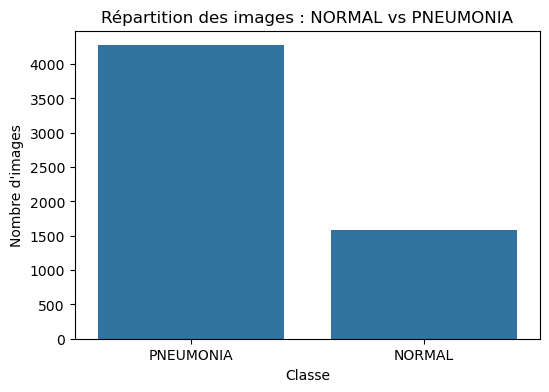

In [7]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=class_counts,
    x="Classe",
    y="Nombre d'images"
)

plt.title("Répartition des images : NORMAL vs PNEUMONIA")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.show()

### Répartition des 2 types de pneumonies

In [8]:
pneumonia_df = df[df["label"] == "PNEUMONIA"]

pneumonia_counts = pneumonia_df["pneumonia_type"].value_counts()
pneumonia_counts

pneumonia_type
bacteria    2780
virus       1493
Name: count, dtype: int64

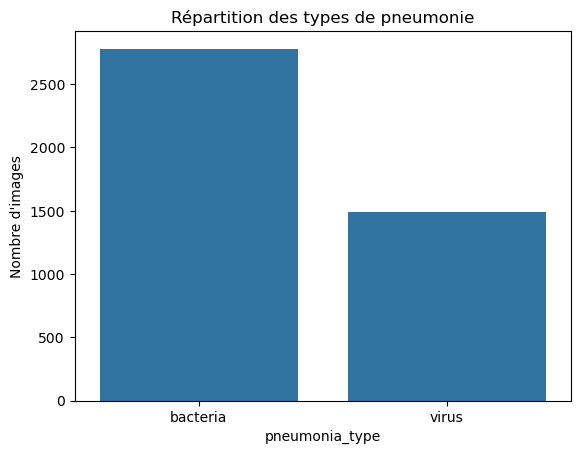

In [9]:
sns.barplot(
    x=pneumonia_counts.index,
    y=pneumonia_counts.values
)
plt.title("Répartition des types de pneumonie")
plt.ylabel("Nombre d'images")
plt.show()

## Sur chaque dataset

   split      label pneumonia_type  count
0   test     NORMAL         Aucune    234
1   test  PNEUMONIA       bacteria    242
2   test  PNEUMONIA          virus    148
3  train     NORMAL         Aucune   1341
4  train  PNEUMONIA       bacteria   2530
5  train  PNEUMONIA          virus   1345
6    val     NORMAL         Aucune      8
7    val  PNEUMONIA       bacteria      8


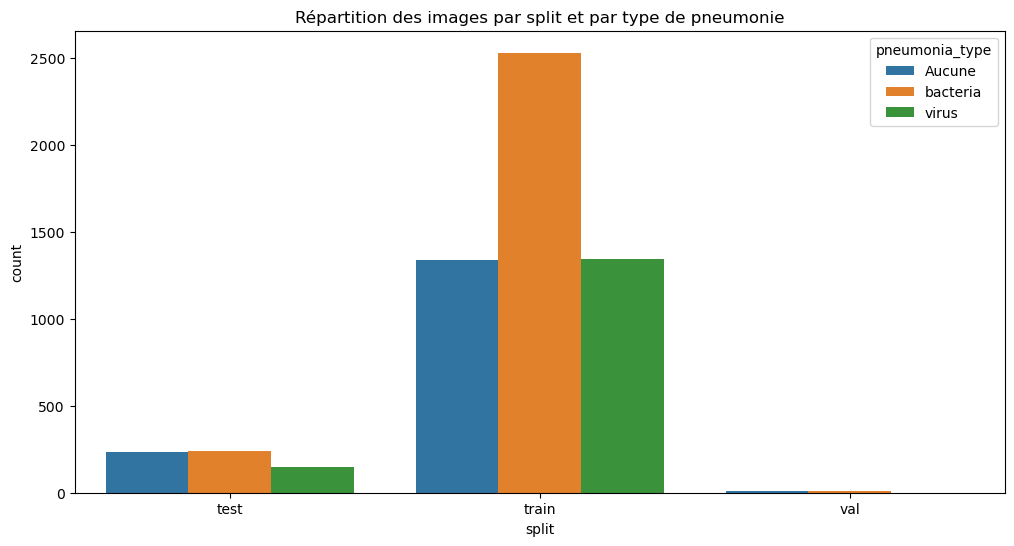

In [10]:
count_split_class_type = (
    df.groupby(["split", "label", "pneumonia_type"])
      .size()
      .reset_index(name="count")
)

print(count_split_class_type)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=count_split_class_type,
    x="split",
    y="count",
    hue="pneumonia_type"
)
plt.title("Répartition des images par split et par type de pneumonie")
plt.show()


# Possibles "pièges" du dataset

## ID de patients communs entre le train et le test

In [14]:
from collections import defaultdict
import re


patients_ambigus = set()
patient_pathologies = defaultdict(set)

# Scan rapide de tout le dataset
for img_path in DATASET_PATH.rglob("*.jp*g"):
    filename = img_path.name.lower()
    
    # Extraction de l'ID
    if "person" in filename:
        pid = re.match(r"(person\d+)", filename)
        pid = pid.group(1) if pid else None
        
    elif filename.startswith("im-"):
        pid = re.match(r"(im-\d+)", filename)
        pid = pid.group(1).upper() if pid else None
        
    else:
        pid = filename.split('_')[0].split('-')[0]
        
    if pid:
        if "bacteria" in filename:
            patient_pathologies[pid].add("BACTERIA")
        elif "virus" in filename:
            patient_pathologies[pid].add("VIRUS")

# Patients avec deux pathologies
for pid, pathologies in patient_pathologies.items():
    if "BACTERIA" in pathologies and "VIRUS" in pathologies:
        patients_ambigus.add(pid)

print(f"ℹ️ {len(patients_ambigus)} patients ambigus détectés.")

ℹ️ 979 patients ambigus détectés.


In [15]:

def extract_patient_ids(split_name):
    patient_ids = set()
    split_path = DATASET_PATH / split_name
    
    # On parcourt récursivement toutes les images (.jpeg ou .jpg) dans les sous-dossiers
    for img_path in split_path.rglob("*.jp*g"):
        filename = img_path.name
        
        # Cas 1 : Format "personXXX_..." (Pneumonie)
        if "person" in filename:
            match = re.match(r"(person\d+)", filename)
            if match:
                patient_ids.add(match.group(1))
        
        # Cas 2 : Format "IM-XXXX-..." (Souvent les cas Normaux)
        elif filename.startswith("IM-"):
            match = re.match(r"(IM-\d+)", filename)
            if match:
                patient_ids.add(match.group(1))
        
        # Cas 3 : Sécurité si le format varie (on prend le premier bloc avant le premier tiret/underscore)
        else:
            fallback_id = filename.split('_')[0].split('-')[0]
            patient_ids.add(fallback_id)
            
    return patient_ids

In [16]:
# Extraction des IDs pour chaque groupe
train_patients = extract_patient_ids("train")
test_patients = extract_patient_ids("test")
val_patients = extract_patient_ids("val") # ou "split" selon ton dossier

print(f"Nombre de patients uniques - Train: {len(train_patients)}, Test: {len(test_patients)}, Val: {len(val_patients)}")

Nombre de patients uniques - Train: 2154, Test: 268, Val: 8


In [17]:
# --- VERIFICATION DES INTERSECTIONS ---
leak_train_test = train_patients.intersection(test_patients)
leak_train_val = train_patients.intersection(val_patients)
leak_val_test = val_patients.intersection(test_patients)

print("\n--- Résultats de la vérification ---")
if leak_train_test:
    print(f"❌ FUITE DÉTECTÉE entre Train et Test ! ({len(leak_train_test)} patients en commun)")
    print(f"IDs corrompus : {list(leak_train_test)}")
else:
    print("✅ Pas de fuite entre Train et Test.")

if leak_train_val:
    print(f"❌ FUITE DÉTECTÉE entre Train et Val ! ({len(leak_train_val)} patients en commun)")
    print(f"IDs corrompus : {list(leak_train_val)}")
else:
    print("✅ Pas de fuite entre Train et Val.")

if leak_val_test:
    print(f"❌ FUITE DÉTECTÉE entre Val et Test ! ({len(leak_val_test)} patients en commun)")
    print(f"IDs corrompus : {list(leak_val_test)}")
else:
    print("✅ Pas de fuite entre Val et Test.")


--- Résultats de la vérification ---
❌ FUITE DÉTECTÉE entre Train et Test ! (171 patients en commun)
IDs corrompus : ['person1608', 'person1673', 'person135', 'person126', 'person143', 'person88', 'person72', 'person122', 'person149', 'person8', 'person1613', 'person1671', 'person1644', 'person104', 'person95', 'person67', 'person61', 'person1665', 'person145', 'person128', 'person1634', 'person34', 'person102', 'person21', 'person147', 'person39', 'person43', 'person45', 'person16', 'person1625', 'person1661', 'person31', 'person62', 'person1619', 'person93', 'person1635', 'person35', 'person1680', 'person111', 'person77', 'person1641', 'person44', 'person118', 'person97', 'person40', 'person64', 'person11', 'person119', 'person23', 'person41', 'person1682', 'person99', 'person3', 'person1667', 'person25', 'person123', 'person1643', 'person74', 'person1674', 'person86', 'person63', 'person1668', 'person113', 'person1640', 'person56', 'person69', 'person137', 'person1685', 'person87',

## Nombre de radiographies par patients, par classe "BACTERIA" ou "VIRUS", par jeu de données

In [18]:
def extract_patient_id(filename):
    filename = filename.lower()

    if "person" in filename:
        match = re.match(r"(person\d+)", filename)
        return match.group(1) if match else None

    elif filename.startswith("im-"):
        match = re.match(r"(im-\d+)", filename)
        return match.group(1).upper() if match else None

    else:
        return filename.split('_')[0].split('-')[0]


df["patient_id"] = df["filename"].apply(extract_patient_id)

df.head()

,split,label,pneumonia_type,filename,path,patient_id
0,train,NORMAL,Aucune,IM-0115-0001.jpeg,data_chest\chest_Xray\train\NORMAL\IM-0115-000...,IM-0115
1,train,NORMAL,Aucune,IM-0117-0001.jpeg,data_chest\chest_Xray\train\NORMAL\IM-0117-000...,IM-0117
2,train,NORMAL,Aucune,IM-0119-0001.jpeg,data_chest\chest_Xray\train\NORMAL\IM-0119-000...,IM-0119
3,train,NORMAL,Aucune,IM-0122-0001.jpeg,data_chest\chest_Xray\train\NORMAL\IM-0122-000...,IM-0122
4,train,NORMAL,Aucune,IM-0125-0001.jpeg,data_chest\chest_Xray\train\NORMAL\IM-0125-000...,IM-0125


In [19]:
counts = (
    df.groupby(
        ["split", "patient_id", "pneumonia_type"]
    )
    .size()
    .reset_index(name="nb_radiographies")
)

counts

,split,patient_id,pneumonia_type,nb_radiographies
0,test,IM-0001,Aucune,1
1,test,IM-0003,Aucune,1
2,test,IM-0005,Aucune,1
3,test,IM-0006,Aucune,1
4,test,IM-0007,Aucune,1
...,...,...,...,...
3234,val,person1949,bacteria,1
3235,val,person1950,bacteria,1
3236,val,person1951,bacteria,1
3237,val,person1952,bacteria,1


In [20]:
pneumo_counts = counts[
    counts["pneumonia_type"].isin(["bacteria", "virus"])
]

pneumo_counts

,split,patient_id,pneumonia_type,nb_radiographies
66,test,person1,virus,7
67,test,person10,virus,1
68,test,person100,bacteria,7
69,test,person101,bacteria,4
70,test,person102,bacteria,1
...,...,...,...,...
3234,val,person1949,bacteria,1
3235,val,person1950,bacteria,1
3236,val,person1951,bacteria,1
3237,val,person1952,bacteria,1


In [ ]:
# Garder uniquement les IDs qui commencent par "person" suivi de chiffres
df_person = df[
    df["patient_id"].str.match(r"^person\d+$", na=False)
]

# Compter les radios par patient et par split
person_counts = (
    df_person
    .groupby(["split", "patient_id"])
    .size()
    .reset_index(name="nb_radiographies")
)

# Garder uniquement ceux avec plus d'une radio
person_multi = person_counts[
    person_counts["nb_radiographies"] > 1
]

person_multi

,split,patient_id,nb_radiographies
0,test,person1,7
2,test,person100,7
3,test,person101,4
5,test,person103,3
6,test,person104,2
...,...,...,...
1833,train,person995,2
1834,train,person996,2
1835,train,person997,2
1836,train,person998,2


In [25]:
len(person_multi["patient_id"].unique())

1060

In [27]:
nb_patients_train = person_multi[person_multi["split"] == "train"]["patient_id"].nunique()
nb_patients_train

1005

# Exploration des caractéristiques des images

In [40]:
widths, heights = [], []

sample_paths = df.sample(200, random_state=42)["path"]

for path in sample_paths:
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f"Largeur moyenne : {np.mean(widths):.1f}")
print(f"Hauteur moyenne : {np.mean(heights):.1f}")
print(f"Largeur min/max : {min(widths)} / {max(widths)}")
print(f"Hauteur min/max : {min(heights)} / {max(heights)}")


Largeur moyenne : 1301.8
Hauteur moyenne : 952.5
Largeur min/max : 486 / 2144
Hauteur min/max : 191 / 2067


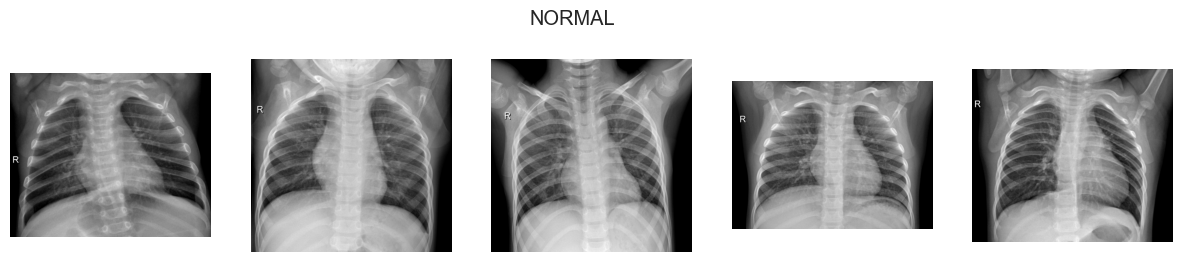

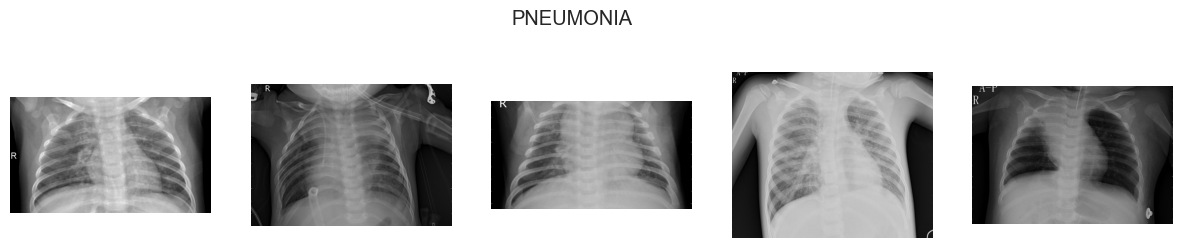

In [42]:
def show_images(df, label, n=5):
    sample = df[df["label"] == label].sample(n)
    plt.figure(figsize=(15, 3))
    for i, path in enumerate(sample["path"]):
        img = Image.open(path)
        plt.subplot(1, n, i + 1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")
    plt.suptitle(label)
    plt.show()

show_images(df, "NORMAL")
show_images(df, "PNEUMONIA")


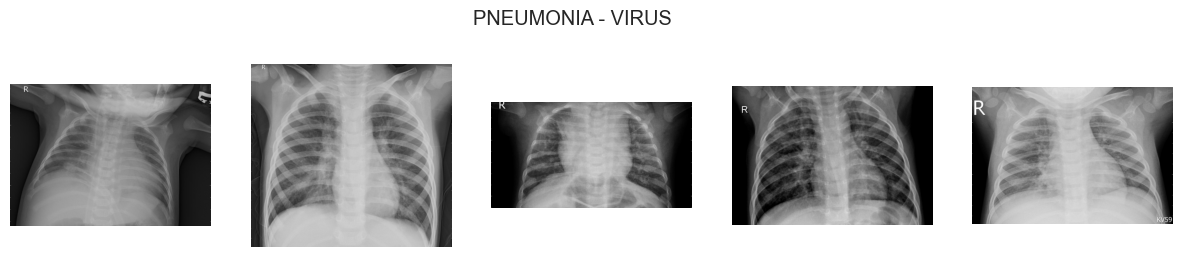

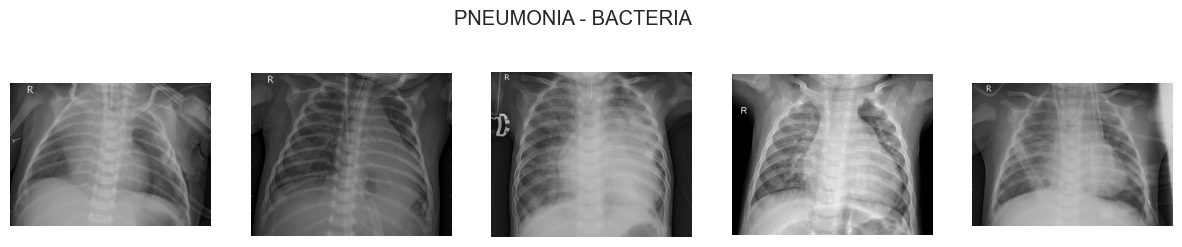

In [43]:
def show_pneumonia_type(df, p_type, n=5):
    sample = df[df["pneumonia_type"] == p_type].sample(n)
    plt.figure(figsize=(15, 3))
    for i, path in enumerate(sample["path"]):
        img = Image.open(path)
        plt.subplot(1, n, i + 1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")
    plt.suptitle(f"PNEUMONIA - {p_type.upper()}")
    plt.show()

show_pneumonia_type(df, "virus")
show_pneumonia_type(df, "bacteria")


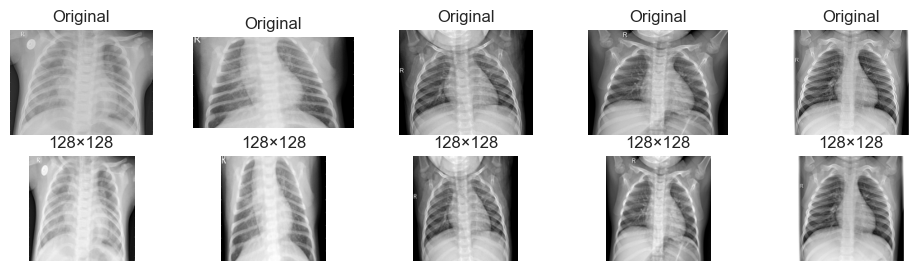

In [45]:
# essai avec image en 128x128
from PIL import Image
import matplotlib.pyplot as plt

TARGET_SIZE = (128, 128)

sample_paths = df.sample(5, random_state=42)["path"]

plt.figure(figsize=(12, 3))
for i, path in enumerate(sample_paths):
    img = Image.open(path).convert("L")
    img_resized = img.resize(TARGET_SIZE)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 5, i + 6)
    plt.imshow(img_resized, cmap="gray")
    plt.title("128×128")
    plt.axis("off")

plt.show()


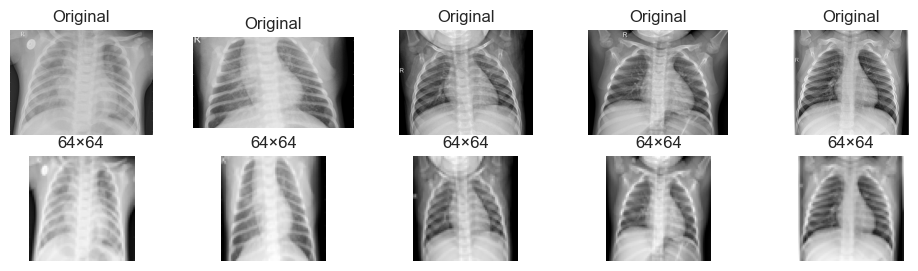

In [48]:
# essai en 64x64

TARGET_SIZE = (64, 64)

sample_paths = df.sample(5, random_state=42)["path"]

plt.figure(figsize=(12, 3))
for i, path in enumerate(sample_paths):
    img = Image.open(path).convert("L")
    img_resized = img.resize(TARGET_SIZE)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 5, i + 6)
    plt.imshow(img_resized, cmap="gray")
    plt.title("64×64")
    plt.axis("off")

plt.show()